In [1]:
import joblib              as jlb
import matplotlib.pyplot   as plt
import pandas as pd
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')
    
from collections           import Counter
from sklearn.decomposition import PCA
from Algorithm             import PAM
from pyclustering.utils import timedcall
from Dataprepare.data_processing import D
from utils.Pam_fast_build import PAM_silhouette_analysis,PAM_davies_bouldin_analysis,PAM_Inertia_analysis

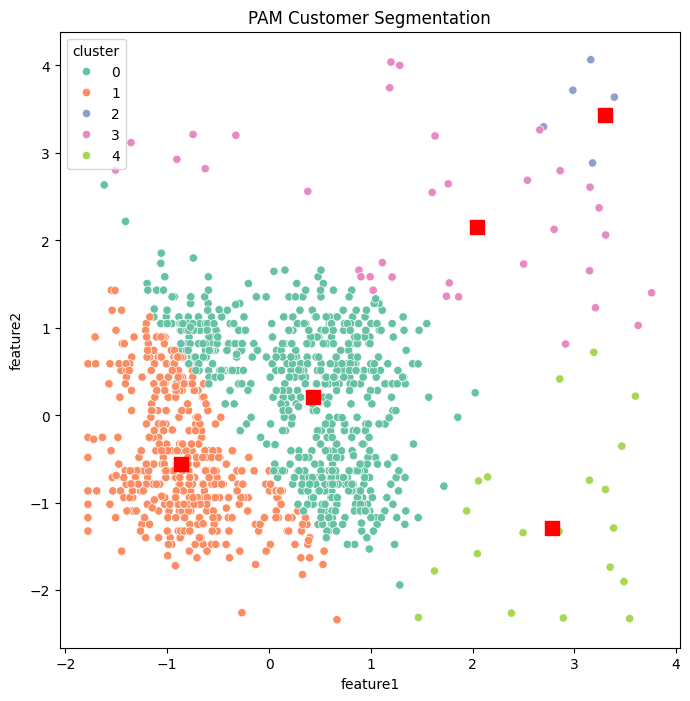

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
D=pd.read_csv(r'datasets/Customers_noise.csv')
features=['income','age']
datas=D[features].copy()
scale=StandardScaler()
scaled_data=scale.fit_transform(datas)
data=pd.DataFrame(scaled_data,columns=features)
model=PAM(data,5)
model.fit()

medoids=model.get_medoids()
labels=model.get_labels()
data['cluster'] = labels

plt.figure(figsize=(8,8))

sns.scatterplot(x=data['income'],
            y=data['age'],
            hue=data['cluster'], palette="Set2")

plt.scatter(medoids[:, 0],
            medoids[:, 1],
            marker='s',
            s=100,color='red'
            )

plt.xlabel("feature1")
plt.ylabel("feature2")
plt.title("PAM Customer Segmentation")

plt.show()

Tiền xử lý dữ liệu

In [2]:
features=['Income','Age','Total_Spend']
data=D[features].copy()
print(data.shape)
print(data.head(1))

(2229, 3)
     Income       Age  Total_Spend
0  0.316484  1.015715     1.205616


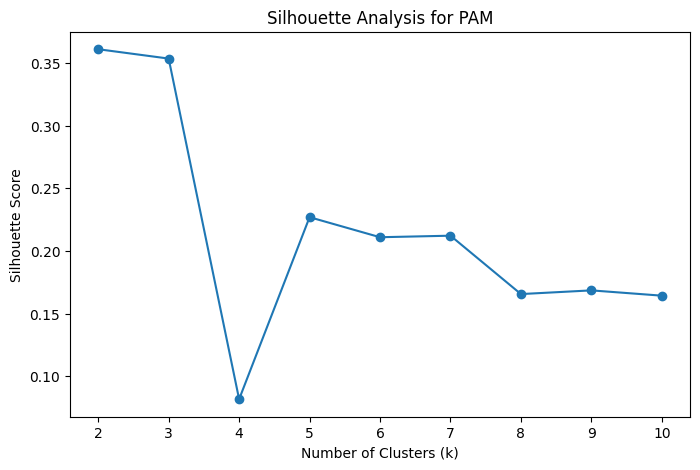

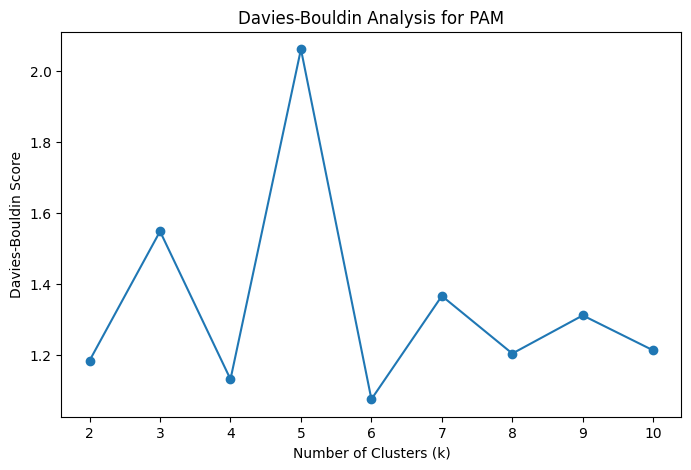

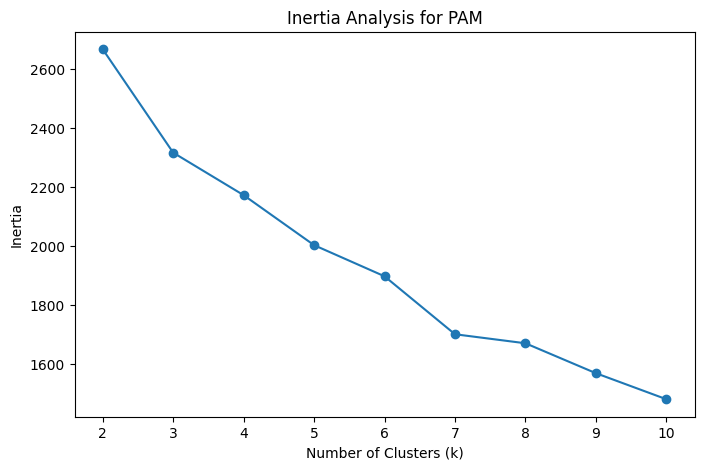

In [3]:
PAM_silhouette_analysis(data, range(2, 11))
PAM_davies_bouldin_analysis(data, range(2, 11))
PAM_Inertia_analysis(data, range(2, 11))

Xây dựng mô hình PAM

In [4]:
k=4
Pam_model=PAM(data,n_clusters = k)
(ticks,results) = timedcall(Pam_model.fit)
print(f'PAM clustering completed in {ticks:.4f} seconds.')

PAM clustering completed in 0.2934 seconds.


In [5]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(Pam_model, '../customer_clustering/Output/PAM.mdl')

['../customer_clustering/Output/PAM.mdl']

In [6]:
## Khai thác mô hình đã được xây dựng
saved=jlb.load('../customer_clustering/Output/PAM.mdl')

In [7]:
## Kết quả gom cụm khách hàng
data['cluster'] = saved.get_labels()

print('\nKích thước các clusters:', Counter(data['cluster']))
print('\n2 clusters lớn nhất:',    Counter(data['cluster']).most_common(2))


Kích thước các clusters: Counter({3: 1044, 1: 548, 2: 331, 0: 306})

2 clusters lớn nhất: [(3, 1044), (1, 548)]


In [8]:
medoids = saved.get_medoids()
labels= saved.get_labels()
print(labels)
print(medoids)

[0 3 2 ... 3 0 3]
[[ 0.53652053  1.27201959  0.74657916]
 [-1.12530759 -0.77842064 -1.06686607]
 [ 1.30121005  0.24679947  1.13265085]
 [-0.01155552 -0.09494056  0.09487989]]


Biểu diễn trực quan

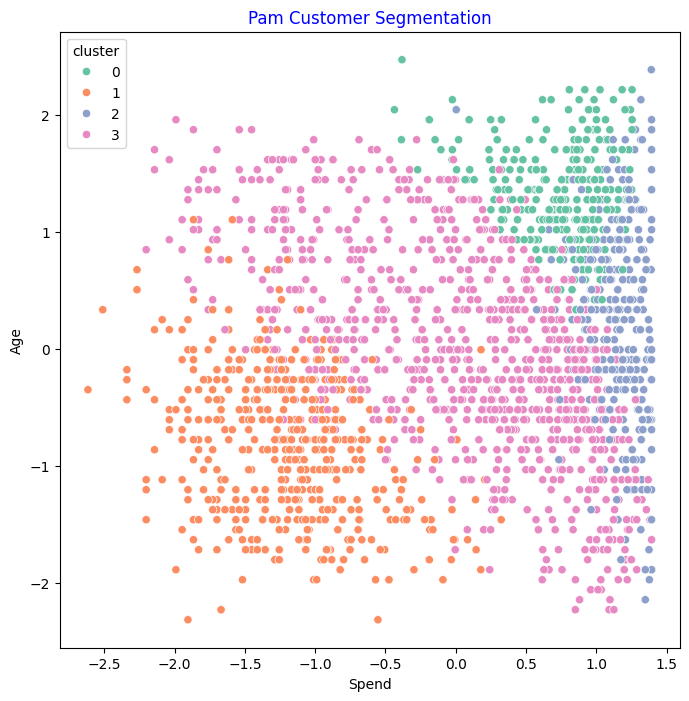

In [12]:
## Biểu diễn trực quan
plt.figure(figsize = (8, 8))
sns.scatterplot(
    x=data['Total_Spend'],
    y=data['Age'],
    hue=data['cluster'],palette="Set2"
)
plt.xlabel('Spend')
plt.ylabel('Age')
plt.title("Pam Customer Segmentation", color = "blue")
plt.show()

In [10]:
pca=PCA(n_components=2)
pca.fit(data)
PCA_ds=pd.DataFrame(pca.transform(data),columns=(['col1','col2']))
print(PCA_ds.describe())

               col1          col2
count  2.229000e+03  2.229000e+03
mean  -9.483466e-17 -1.554013e-16
std    1.389395e+00  1.167928e+00
min   -3.587207e+00 -2.893654e+00
25%   -1.224688e+00 -4.995165e-01
50%    2.571946e-01  1.574966e-01
75%    1.170325e+00  9.145592e-01
max    2.892479e+00  1.968923e+00


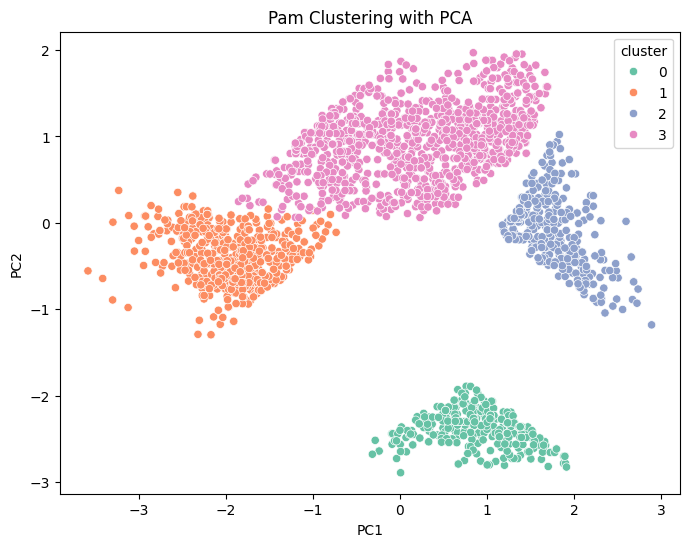

In [13]:

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=PCA_ds['col1'],
    y=PCA_ds['col2'],
    hue=data['cluster'],
    palette='Set2'
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Pam Clustering with PCA')
plt.show()